In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('dados-2026.csv')

df['DT_VENDA'] = pd.to_datetime(df['DT_VENDA'])
df['DT_VCT'] = pd.to_datetime(df['DT_VCT'], errors='coerce')
df['DT_PGTO'] = pd.to_datetime(df['DT_PGTO'], errors='coerce')

df['VLR_VENDA'] = (
    df['VLR_VENDA']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace(',', '', regex=False)  
    .astype(float)
)

df['ANO_VENDA'] = df['DT_VENDA'].dt.year
df['PRAZO_DIAS'] = (df['DT_VCT'] - df['DT_VENDA']).dt.days
df['DIAS_ATRASO_PGTO'] = (df['DT_PGTO'] - df['DT_VCT']).dt.days 

print(f"Dataset carregado: {df.shape[0]} registros")
print(f"Colunas convertidas: DT_VENDA, DT_VCT, DT_PGTO, VLR_VENDA")
print(f"Colunas derivadas criadas: ANO_VENDA, PRAZO_DIAS, DIAS_ATRASO_PGTO")

Dataset carregado: 100 registros
Colunas convertidas: DT_VENDA, DT_VCT, DT_PGTO, VLR_VENDA
Colunas derivadas criadas: ANO_VENDA, PRAZO_DIAS, DIAS_ATRASO_PGTO


In [9]:
# ===============
# FUNÇÕES HELPER 
# ===============

def clientes_por_ano(ano):
    """Retorna set de clientes que compraram em um ano específico"""
    return set(df[df['ANO_VENDA'] == ano]['ID_CLIENTE'])


def vendas_por_ano(ano):
    """Retorna DataFrame filtrado por ano"""
    return df[df['ANO_VENDA'] == ano]


def saldo_em_aberto(data_corte):
    """
    Calcula saldo em aberto na data de corte.
    
    Vendas em aberto: vencimento <= data_corte E (não paga OU paga após data)
    """
    data_corte = pd.to_datetime(data_corte)
    
    if isinstance(data_corte, str):
        data_corte = pd.to_datetime(data_corte)
    
    vendas = df[
        (df['DT_VCT'] <= data_corte) &
        (
            df['DT_PGTO'].isna() |
            (df['DT_PGTO'] > data_corte)
        )
    ].copy()
    
    vendas['ATRASO_A_DATA_CORTE'] = vendas.apply(
        lambda row: (data_corte - row['DT_VCT']).days 
        if pd.isna(row['DT_PGTO']) 
        else (row['DT_PGTO'] - row['DT_VCT']).days,
        axis=1
    )
    
    return vendas


def inadimplencia_por_dias(data_corte, dias_atraso):
    """
    Calcula inadimplência absoluta e percentual.
    
    Args:
        data_corte: Data para cálculo do saldo
        dias_atraso: Mínimo de dias de atraso para considerar
    """
    vendas = saldo_em_aberto(data_corte)
    vendas_atraso = vendas[vendas['ATRASO_A_DATA_CORTE'] > dias_atraso]
    
    saldo_total = vendas['VLR_VENDA'].sum()
    saldo_atraso = vendas_atraso['VLR_VENDA'].sum()
    percentual = (saldo_atraso / saldo_total * 100) if saldo_total > 0 else 0
    
    return saldo_atraso, percentual

## 1. Quantos clientes únicos realizaram compras em 2022?

In [10]:
clientes_2022 = clientes_por_ano(2022)
print(f"Total de clientes únicos em 2022: {len(clientes_2022)}")

Total de clientes únicos em 2022: 31


## 2. Qual a quantidade de vendas realizadas em 2022? E 2023?

In [11]:
vendas_por_ano_count = df['ANO_VENDA'].value_counts().sort_index()

print(f"Vendas em 2022: {vendas_por_ano_count.get(2022, 0)}")
print(f"Vendas em 2023: {vendas_por_ano_count.get(2023, 0)}")

Vendas em 2022: 56
Vendas em 2023: 44


## 3. Qual o valor médio das vendas em 2022 e em 2023?

In [12]:
media_por_ano = df.groupby('ANO_VENDA')['VLR_VENDA'].mean()

print(f"Valor médio das vendas em 2022: R$ {media_por_ano.get(2022, 0):,.2f}")
print(f"Valor médio das vendas em 2023: R$ {media_por_ano.get(2023, 0):,.2f}")

Valor médio das vendas em 2022: R$ 251,803.57
Valor médio das vendas em 2023: R$ 242,022.73


## 4. Qual o prazo contratado médio por ano (em dias)?

In [13]:
df_prazo_valido = df[df['PRAZO_DIAS'] >= 0]
prazo_medio_por_ano = df_prazo_valido.groupby('ANO_VENDA')['PRAZO_DIAS'].mean().sort_index()

print("Prazo contratado médio por ano (em dias):")
for ano, prazo in prazo_medio_por_ano.items():
    print(f"{ano}: {prazo:.0f} dias")

Prazo contratado médio por ano (em dias):
2022: 196 dias
2023: 193 dias


## 5. Quantas vendas foram pagas em dia ou antecipadas?

In [14]:
df_pagas = df[df['DT_PGTO'].notna()]
vendas_em_dia = df_pagas[df_pagas['DIAS_ATRASO_PGTO'] <= 0]  # PGTO <= VCT

total_em_dia = vendas_em_dia.shape[0]
total_pagas = df_pagas.shape[0]
percentual = (total_em_dia / total_pagas * 100) if total_pagas > 0 else 0

print(f"Vendas pagas em dia ou antecipadas: {total_em_dia}")
print(f"Total de vendas pagas: {total_pagas}")
print(f"Percentual: {percentual:.2f}%")

Vendas pagas em dia ou antecipadas: 34
Total de vendas pagas: 81
Percentual: 41.98%


## 6. Quantas vendas em atraso > 90 dias?

In [15]:
# Vendas pagas com atraso > 90 dias
vendas_pagas_atraso_90 = df_pagas[df_pagas['DIAS_ATRASO_PGTO'] > 90].shape[0]

# Vendas não pagas vencidas há > 90 dias
hoje = pd.Timestamp.now()
df_nao_pagas = df[df['DT_PGTO'].isna()]
vendas_nao_pagas_atraso_90 = df_nao_pagas[
    (hoje - df_nao_pagas['DT_VCT']).dt.days > 90
].shape[0]

total_atraso_90 = vendas_pagas_atraso_90 + vendas_nao_pagas_atraso_90

print(f"Vendas pagas com atraso > 90 dias: {vendas_pagas_atraso_90}")
print(f"Vendas não pagas vencidas há > 90 dias: {vendas_nao_pagas_atraso_90}")
print(f"TOTAL de vendas em atraso > 90 dias: {total_atraso_90}")

Vendas pagas com atraso > 90 dias: 5
Vendas não pagas vencidas há > 90 dias: 19
TOTAL de vendas em atraso > 90 dias: 24


## 7. Quantos clientes atrasaram > 90 dias?

In [16]:
# Clientes que pagaram após > 90 dias
clientes_atraso_pago = set(df_pagas[df_pagas['DIAS_ATRASO_PGTO'] > 90]['ID_CLIENTE'])

# Clientes com dívidas vencidas há > 90 dias
clientes_atraso_nao_pago = set(df_nao_pagas[
    (hoje - df_nao_pagas['DT_VCT']).dt.days > 90
]['ID_CLIENTE'])

total_clientes_atraso_90 = clientes_atraso_pago.union(clientes_atraso_nao_pago)

print(f"Clientes que atrasaram > 90 dias (pagos após vencimento): {len(clientes_atraso_pago)}")
print(f"Clientes com dívidas vencidas há > 90 dias (ainda não pagas): {len(clientes_atraso_nao_pago)}")
print(f"TOTAL de clientes únicos em atraso > 90 dias: {len(total_clientes_atraso_90)}")

Clientes que atrasaram > 90 dias (pagos após vencimento): 5
Clientes com dívidas vencidas há > 90 dias (ainda não pagas): 16
TOTAL de clientes únicos em atraso > 90 dias: 20


## 8. Saldo a receber em 31/10/2022

In [17]:
vendas_abertas = saldo_em_aberto('2022-10-31')
saldo = vendas_abertas['VLR_VENDA'].sum()

print(f"Saldo a receber em 31/10/2022: R$ {saldo:,.2f}")
print(f"Quantidade de vendas em aberto: {vendas_abertas.shape[0]}")

Saldo a receber em 31/10/2022: R$ 1,265,000.00
Quantidade de vendas em aberto: 6


## 9. Saldo a receber em 31/08/2022

In [18]:
vendas_abertas = saldo_em_aberto('2022-08-31')
saldo = vendas_abertas['VLR_VENDA'].sum()

print(f"Saldo a receber em 31/08/2022: R$ {saldo:,.2f}")
print(f"Quantidade de vendas em aberto: {vendas_abertas.shape[0]}")

Saldo a receber em 31/08/2022: R$ 340,000.00
Quantidade de vendas em aberto: 2


## 10. Percentual do valor pago no prazo

In [19]:
df_pagas = df[df['DT_PGTO'].notna()]
vendas_em_dia = df_pagas[df_pagas['DIAS_ATRASO_PGTO'] <= 0]

valor_pago_prazo = vendas_em_dia['VLR_VENDA'].sum()
valor_total_pagas = df_pagas['VLR_VENDA'].sum()
percentual = (valor_pago_prazo / valor_total_pagas * 100) if valor_total_pagas > 0 else 0

print(f"Valor pago no prazo: R$ {valor_pago_prazo:,.2f}")
print(f"Valor total das vendas pagas: R$ {valor_total_pagas:,.2f}")
print(f"Percentual pago no prazo: {percentual:.2f}%")

Valor pago no prazo: R$ 10,260,000.00
Valor total das vendas pagas: R$ 21,459,000.00
Percentual pago no prazo: 47.81%


## 11. Percentual de vendas pagas no prazo

In [20]:
total_em_dia = vendas_em_dia.shape[0]
total_pagas = df_pagas.shape[0]
percentual = (total_em_dia / total_pagas * 100) if total_pagas > 0 else 0

print(f"Vendas pagas no prazo: {total_em_dia}")
print(f"Total de vendas pagas: {total_pagas}")
print(f"Percentual de vendas pagas no prazo: {percentual:.2f}%")

Vendas pagas no prazo: 34
Total de vendas pagas: 81
Percentual de vendas pagas no prazo: 41.98%


## 12. Clientes ativos em 2023

In [21]:
clientes_2023 = clientes_por_ano(2023)
print(f"Clientes ativos em 2023: {len(clientes_2023)}")

Clientes ativos em 2023: 26


## 13. Prazo contratado médio ponderado (2022-2023)

In [22]:
df_2022_2023 = df[df['ANO_VENDA'].isin([2022, 2023])]
df_2022_2023 = df_2022_2023[df_2022_2023['PRAZO_DIAS'] >= 0]

soma_prazo_valor = (df_2022_2023['PRAZO_DIAS'] * df_2022_2023['VLR_VENDA']).sum()
soma_valor_total = df_2022_2023['VLR_VENDA'].sum()

prazo_medio_ponderado = soma_prazo_valor / soma_valor_total if soma_valor_total > 0 else 0

print(f"Prazo contratado médio ponderado (2022-2023): {prazo_medio_ponderado:.0f} dias")

Prazo contratado médio ponderado (2022-2023): 197 dias


## 14. Percentual do saldo em aberto com atraso > 90 dias em 31/12/2023

In [23]:
saldo_90, percentual_90 = inadimplencia_por_dias('2023-12-31', 90)

vendas_abertas = saldo_em_aberto('2023-12-31')
saldo_aberto_total = vendas_abertas['VLR_VENDA'].sum()

print(f"Saldo em aberto total em 31/12/2023: R$ {saldo_aberto_total:,.2f}")
print(f"Saldo em aberto com atraso > 90 dias: R$ {saldo_90:,.2f}")
print(f"Percentual do saldo em aberto com atraso > 90 dias: {percentual_90:.2f}%")

Saldo em aberto total em 31/12/2023: R$ 3,181,000.00
Saldo em aberto com atraso > 90 dias: R$ 2,581,000.00
Percentual do saldo em aberto com atraso > 90 dias: 81.14%


## 15. Inadimplência financeira (atraso > 180 dias) em 31/12/2023

In [24]:
saldo_180, percentual_180 = inadimplencia_por_dias('2023-12-31', 180)

print(f"Inadimplência financeira (atraso > 180 dias) em 31/12/2023:")
print(f"Absoluta: R$ {saldo_180:,.2f}")
print(f"Percentual: {percentual_180:.2f}%")

Inadimplência financeira (atraso > 180 dias) em 31/12/2023:
Absoluta: R$ 2,106,000.00
Percentual: 66.21%


## 16. Atraso médio para faturas pagas com atraso

In [25]:
df_pagas = df[df['DT_PGTO'].notna()]
vendas_pagas_com_atraso = df_pagas[df_pagas['DIAS_ATRASO_PGTO'] > 0]

atraso_medio = vendas_pagas_com_atraso['DIAS_ATRASO_PGTO'].mean()

print(f"Total de vendas pagas com atraso: {vendas_pagas_com_atraso.shape[0]}")
print(f"Atraso médio para faturas pagas com atraso: {atraso_medio:.0f} dias")

Total de vendas pagas com atraso: 47
Atraso médio para faturas pagas com atraso: 33 dias


## 17. Churn absoluto em 2023

In [26]:
clientes_2022 = clientes_por_ano(2022)
clientes_2023 = clientes_por_ano(2023)

churn_clientes = clientes_2022 - clientes_2023
churn_absoluto = len(churn_clientes)

print(f"Clientes em 2022: {len(clientes_2022)}")
print(f"Clientes em 2023: {len(clientes_2023)}")
print(f"\nChurn absoluto em 2023: {churn_absoluto} clientes")
print(f"Clientes que retornaram: {len(clientes_2022 & clientes_2023)}")
print(f"Novos clientes em 2023: {len(clientes_2023 - clientes_2022)}")

Clientes em 2022: 31
Clientes em 2023: 26

Churn absoluto em 2023: 16 clientes
Clientes que retornaram: 15
Novos clientes em 2023: 11


## 18. Novos clientes em 2023

In [27]:
novos_clientes_2023 = clientes_2023 - clientes_2022
print(f"Novos clientes em 2023: {len(novos_clientes_2023)}")

Novos clientes em 2023: 11


## 19. Participação do faturamento de 2023

In [28]:
faturamento_por_ano = df.groupby('ANO_VENDA')['VLR_VENDA'].sum()
faturamento_total = faturamento_por_ano.sum()
faturamento_2023 = faturamento_por_ano.get(2023, 0)
participacao_2023 = (faturamento_2023 / faturamento_total * 100) if faturamento_total > 0 else 0

print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Faturamento 2023: R$ {faturamento_2023:,.2f}")
print(f"\nParticipação do faturamento de 2023: {participacao_2023:.2f}%")
print(f"\nFaturamento por ano:")
for ano, valor in faturamento_por_ano.items():
    part = (valor / faturamento_total * 100) if faturamento_total > 0 else 0
    print(f"{ano}: R$ {valor:,.2f} ({part:.2f}%)")

Faturamento total: R$ 24,750,000.00
Faturamento 2023: R$ 10,649,000.00

Participação do faturamento de 2023: 43.03%

Faturamento por ano:
2022: R$ 14,101,000.00 (56.97%)
2023: R$ 10,649,000.00 (43.03%)


/tmp/ipykernel_57180/3695478905.py:99: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


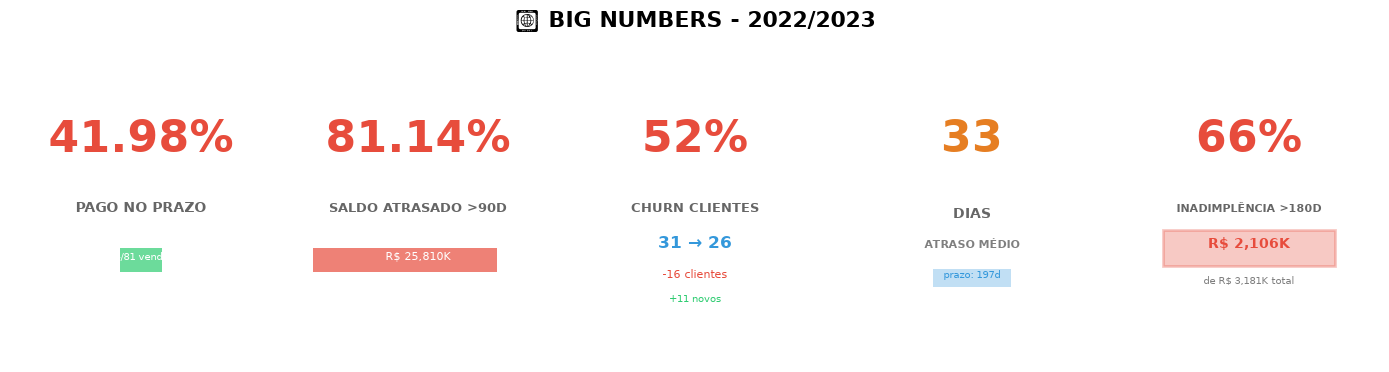

In [ ]:
# Big Numbers Dashboard

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Cores
C_VERDE = '#2ecc71'
C_VERMELHO = '#e74c3c'
C_LARANJA = '#e67e22'
C_AMARELO = '#f1c40f'
C_AZUL = '#3498db'

fig = plt.figure(figsize=(14, 4))
fig.suptitle('📊 BIG NUMBERS - 2022/2023', fontsize=16, fontweight='bold', y=0.98)

# ──────────────────────────────────────────────────────────────────
# MÉTRICA 1: % Pago no Prazo
# ──────────────────────────────────────────────────────────────────

ax1 = plt.subplot2grid((1, 5), (0, 0))

ax1.text(0.5, 0.7, '41.98%', ha='center', fontsize=32, fontweight='bold',
         color=C_VERDE if 41.98 > 50 else C_VERMELHO)
ax1.text(0.5, 0.5, 'PAGO NO PRAZO', ha='center', fontsize=10, weight='bold', alpha=0.6)

bar = plt.Rectangle((0.42, 0.3), 0.16, 0.08, facecolor=C_VERDE, alpha=0.7)
ax1.add_patch(bar)
ax1.text(0.5, 0.34, '34/81 vendas', ha='center', fontsize=7, color='white')

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# ──────────────────────────────────────────────────────────────────
# MÉTRICA 2: Saldo Atraso >90 dias
# ──────────────────────────────────────────────────────────────────

ax2 = plt.subplot2grid((1, 5), (0, 1))

ax2.text(0.5, 0.7, '81.14%', ha='center', fontsize=32, fontweight='bold', color=C_VERMELHO)
ax2.text(0.5, 0.5, 'SALDO ATRASADO >90D', ha='center', fontsize=9, weight='bold', alpha=0.6)

bar_verm = plt.Rectangle((0.1, 0.3), 0.7, 0.08, facecolor=C_VERMELHO, alpha=0.7)
ax2.add_patch(bar_verm)
ax2.text(0.5, 0.34, 'R$ 25,810K', ha='center', fontsize=8, color='white')

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# ──────────────────────────────────────────────────────────────────
# MÉTRICA 3: Churn
# ──────────────────────────────────────────────────────────────────

ax3 = plt.subplot2grid((1, 5), (0, 2))

ax3.text(0.5, 0.7, '52%', ha='center', fontsize=32, fontweight='bold', color=C_VERMELHO)
ax3.text(0.5, 0.5, 'CHURN CLIENTES', ha='center', fontsize=9, weight='bold', alpha=0.6)

ax3.text(0.5, 0.38, '31 → 26', ha='center', fontsize=12, fontweight='bold', color=C_AZUL)
ax3.text(0.5, 0.28, '-16 clientes', ha='center', fontsize=8, color=C_VERMELHO)
ax3.text(0.5, 0.20, '+11 novos', ha='center', fontsize=7, color=C_VERDE)

ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# ──────────────────────────────────────────────────────────────────
# MÉTRICA 4: Atraso Médio
# ──────────────────────────────────────────────────────────────────

ax4 = plt.subplot2grid((1, 5), (0, 3))

ax4.text(0.5, 0.7, '33', ha='center', fontsize=32, fontweight='bold', color=C_LARANJA)
ax4.text(0.5, 0.48, 'DIAS', ha='center', fontsize=10, weight='bold', alpha=0.6)
ax4.text(0.5, 0.38, 'ATRASO MÉDIO', ha='center', fontsize=8, weight='bold', alpha=0.5)

bar_prazo = plt.Rectangle((0.35, 0.25), 0.3, 0.06, facecolor=C_AZUL, alpha=0.3)
ax4.add_patch(bar_prazo)
ax4.text(0.5, 0.28, 'prazo: 197d', ha='center', fontsize=7, color=C_AZUL)

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

# ──────────────────────────────────────────────────────────────────
# MÉTRICA 5: Inadimplência >180 dias
# ──────────────────────────────────────────────────────────────────

ax5 = plt.subplot2grid((1, 5), (0, 4))

ax5.text(0.5, 0.7, '66%', ha='center', fontsize=32, fontweight='bold', color=C_VERMELHO)
ax5.text(0.5, 0.5, 'INADIMPLÊNCIA >180D', ha='center', fontsize=8, weight='bold', alpha=0.6)

bar_inad = plt.Rectangle((0.17, 0.32), 0.66, 0.12, facecolor=C_VERMELHO, alpha=0.3, edgecolor=C_VERMELHO, linewidth=2)
ax5.add_patch(bar_inad)
ax5.text(0.5, 0.38, 'R$ 2,106K', ha='center', fontsize=10, fontweight='bold', color=C_VERMELHO)
ax5.text(0.5, 0.26, 'de R$ 3,181K total', ha='center', fontsize=7, alpha=0.5)

ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)
ax5.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.1)
print()